In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# mauvaise extension !!!! c'est un xlsx
source = "./279493_Novapress850_H2_1-mm.xls"

# xls => pip install xlrd
# xlsx => pip install openpyxl
xlsx = pd.ExcelFile(source, engine="openpyxl")

for nom in xlsx.sheet_names:
  print(nom)

Données
DonnéesT
DonnéesT2
Description
Légend
Feuil3


In [ ]:
donnees = pd.read_excel(
  source,
  sheet_name="Données",
  engine="openpyxl",
  # 4 premières colonnes en indice car les noms sont imbitables
  usecols=list(range(4))
)
# renommer de façon pratique
donnees.columns = ["temps_s", "contrainte_MPa", "pression_bar", "fuite_mg_s_m"]
donnees.head()

,temps_s,contrainte_MPa,pression_bar,fuite_mg_s_m
0,54.110271,0.338408,0.182359,4.595925e-07
1,54.210251,0.357448,0.181996,4.592784e-07
2,54.310534,0.370948,0.179501,4.597373e-07
3,54.411011,0.395490,0.182117,4.595592e-07
4,54.511138,0.432808,0.182670,4.595572e-07


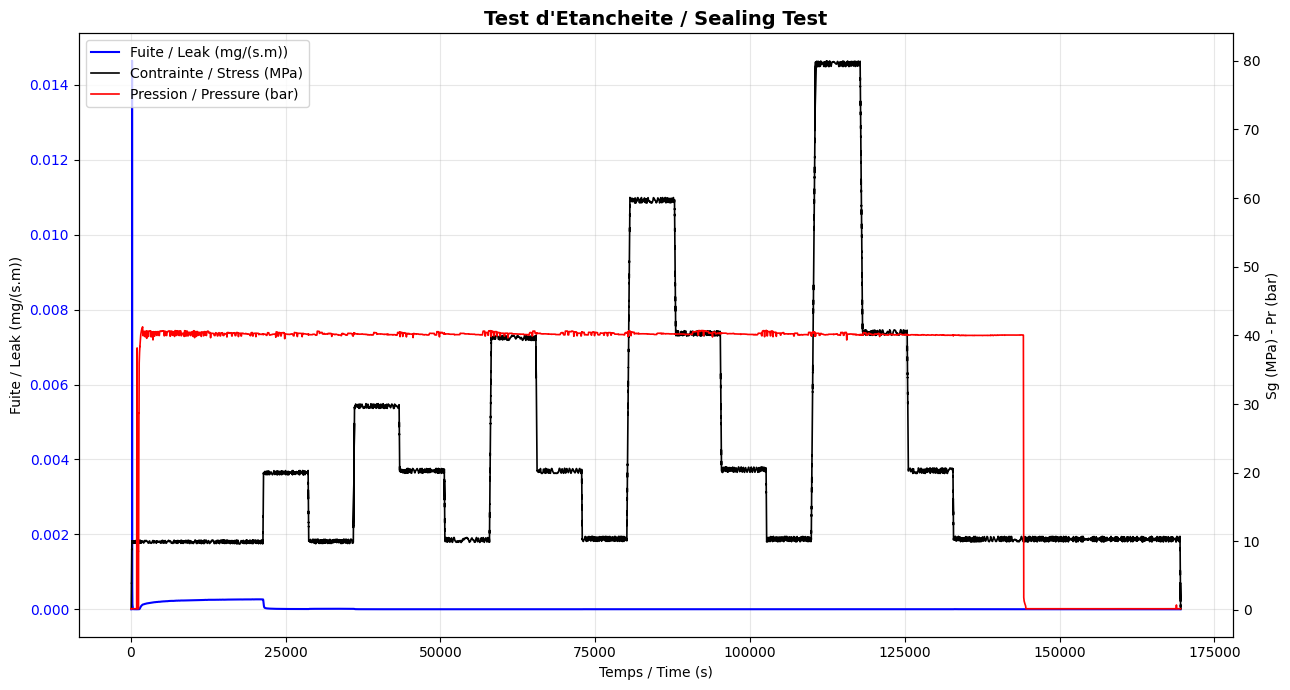

In [21]:
# dessiner les 3 courbes sur la même figure sans subplots => twinx
fig, ax_gauche = plt.subplots(figsize=(13, 7))

courbe_fuite = ax_gauche.plot(
  donnees["temps_s"], 
  donnees["fuite_mg_s_m"],
  # bcp de paramètres cosmétiques viennent du **kwargs => chercher dans la doc matplotlib
  color="blue", label="Fuite / Leak (mg/(s.m))", linewidth=1.5
)[0]

ax_gauche.set_xlabel("Temps / Time (s)")
ax_gauche.set_ylabel("Fuite / Leak (mg/(s.m))")
ax_gauche.tick_params(axis="y", labelcolor="blue")
# ---------------------- 2ème courbe -------------------

# superposition de la 2ème sur la 1ère
ax_droite = ax_gauche.twinx()
# plot => retourne une liste ici de longueur 1 je fais un unpacking à 1 élément
courbe_contrainte = ax_droite.plot(
    donnees["temps_s"], donnees["contrainte_MPa"],
    color="black", linewidth=1.2, label="Contrainte / Stress (MPa)",
)[0]
courbe_pression = ax_droite.plot(
    donnees["temps_s"], donnees["pression_bar"],
    color="red", linewidth=1.2, label="Pression / Pressure (bar)",
)[0]
ax_droite.set_ylabel("Sg (MPa) - Pr (bar)")

# ----------------------- Titre , Legend ----------------------
plt.title("Test d'Etancheite / Sealing Test", fontsize=14, fontweight="bold")

courbes = [courbe_fuite, courbe_contrainte, courbe_pression]
# -------------- objet courbe , les labels des courbes, où la mettre 
ax_gauche.legend(courbes, [c.get_label() for c in courbes], loc="upper left")
ax_gauche.grid(True, alpha=0.3)
fig.tight_layout()
# afficher
plt.show()